# Setup environment and load data

Dataset: https://s3.hothienlac.com/yomitoon/sales_data.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/sales_data.csv")
df.head()


,order_id,order_date,customer_id,customer_name,city,product,category,quantity,unit_price,payment_method
0,1001,2024-01-02,C001,Alice,New York,Laptop,Electronics,1,1200,Credit Card
1,1002,2024-01-02,C002,Bob,Los Angeles,Headphones,Electronics,2,150,PayPal
2,1003,2024-01-03,C003,Charlie,New York,Office Chair,Furniture,1,350,Credit Card
3,1004,2024-01-03,C001,Alice,New York,Mouse,Electronics,3,25,Debit Card
4,1005,2024-01-04,C004,Diana,Chicago,Desk,Furniture,1,500,Bank Transfer


# 🟡 LEVEL 4 — Analytical Aggregation (Score 4–6)

## **Q8. Average order value (AOV) per customer**

### Task

For each customer, compute:

* total spending
* number of orders
* **average order value**

### 💡 Hint

Use:

* `.groupby()`
* `.agg()`
* basic arithmetic between aggregated columns

### 📚 Reference

* [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)
* [https://pandas.pydata.org/docs/user_guide/groupby.html](https://pandas.pydata.org/docs/user_guide/groupby.html)

### 🧠 Explanation

This teaches:

* multi-metric aggregation
* **ratio metrics** (very common in dashboards)
* separating *raw data* from *business KPIs*

Tính tổng chi tiêu: gom dữ liệu theo từng khách hàng rồi tính tổng doanh thu mỗi khách sau đó đếm số đơn hàng của mỗi khách

In [ ]:
df['amount'] = df['quantity'] * df['unit_price']

summary = df.groupby('customer_id').agg(
    total_spending=('amount', 'sum'),
    number_of_orders=('order_id', 'nunique')
)

summary

,total_spending,number_of_orders
customer_id,,
C001,1355,3
C002,900,2
C003,440,2
C004,500,1
C005,1100,1
C006,600,1


AOV là một KPI dùng trong phân tích kinh doanh vì nó cho biết mỗi đơn hàng trung bình mang lại bao nhiêu doanh thu.

In [ ]:
summary['AOV'] = summary['total_spending'] / summary['number_of_orders']
summary


,total_spending,number_of_orders,AOV
customer_id,,,
C001,1355,3,451.666667
C002,900,2,450.000000
C003,440,2,220.000000
C004,500,1,500.000000
C005,1100,1,1100.000000
C006,600,1,600.000000


Kết quả cho thấy mỗi khách hàng có hành vi chi tiêu khác nhau.
Những khách hàng có AOV cao thường đặt các đơn hàng giá trị lớn và là nhóm khách hàng tiềm năng.

## **Q9. Revenue contribution by category (%)**

### Task

Calculate:

* total revenue per product category
* percentage contribution of each category to total revenue

### 💡 Hint

Use:

* `.groupby()`
* `.sum()`
* `.assign()`
* division by a **global scalar**

### 📚 Reference

* [https://pandas.pydata.org/docs/reference/api/pandas.Series.div.html](https://pandas.pydata.org/docs/reference/api/pandas.Series.div.html)

### 🧠 Explanation

You learn:

* **normalization**
* how to compare groups on the same scale
* how to prepare data for **pie charts / stacked bars**

Mục tiêu của bài này là xác định mỗi danh mục sản phẩm đóng góp bao nhiêu phần trăm vào tổng doanh thu.

In [ ]:
df[['category', 'amount']].head()


,category,amount
0,Electronics,1200
1,Electronics,300
2,Furniture,350
3,Electronics,75
4,Furniture,500


groupby('category').sum() để tính tổng doanh thu theo từng danh mục. Chia doanh thu từng danh mục cho tổng doanh thu toàn bộ dataset Nhân 100 để chuyển sang dạng phần trăm

In [ ]:
revenue_by_category = df.groupby('category')['amount'].sum()

revenue_by_category


,amount
category,
Electronics,3955
Furniture,940


In [ ]:
revenue_pct = revenue_by_category / revenue_by_category.sum() * 100

revenue_pct


,amount
category,
Electronics,80.796731
Furniture,19.203269


Phân tích cho thấy có những danh mục đóng góp doanh thu lớn hơn hẳn so với các danh mục còn lại.
Điều này giúp ta xác dịnh các danh mục chủ lực và các danh mục kém hiệu quả để tối ưu hoặc loại bỏ

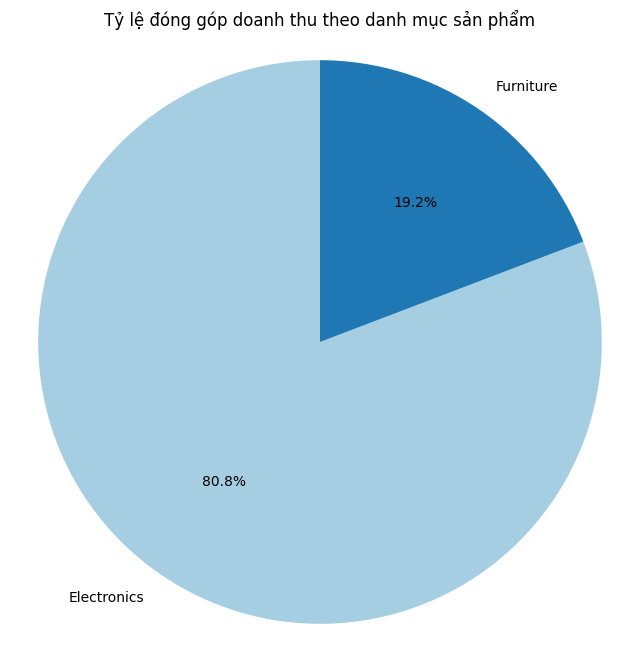

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(revenue_pct, labels=revenue_pct.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Tỷ lệ đóng góp doanh thu theo danh mục sản phẩm')
plt.axis('equal') # Ensures the pie chart is circular.
plt.show()

# 🔵 LEVEL 5 — Distribution, Ranking & Segmentation (Score 7–8)

## **Q10. Identify top 20% customers by revenue (Pareto analysis)**

### Task

Determine:

* which customers belong to the **top 20%** by total spending

### 💡 Hint

Use:

* `.sort_values()`
* `.cumsum()`
* `.quantile()`

### 📚 Reference

* [https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html](https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html)

### 🧠 Explanation

This is a classic **80/20 rule** problem:

* who really drives revenue?
* foundational for **customer segmentation**

Bài này áp dụng nguyên lý Pareto (80/20) để tìm ra nhóm khách hàng quan trọng nhất.

Gom theo khách hàng

Sắp xếp giảm dần để khách chi tiêu nhiều nhất đứng đầu

In [ ]:
customer_revenue = (
    df.groupby("customer_id")["amount"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue

,amount
customer_id,
C001,1355
C005,1100
C002,900
C006,600
C004,500
C003,440


cumsum(): cộng dồn doanh thu

Chia cho tổng doanh thu → tỷ lệ tích lũy

In [ ]:
revenue_cumsum = customer_revenue.cumsum()
revenue_percent = revenue_cumsum / customer_revenue.sum()

revenue_percent


,amount
customer_id,
C001,0.276813
C005,0.501532
C002,0.685393
C006,0.807967
C004,0.910112
C003,1.000000


Lấy các khách hàng tạo ra 20% doanh thu đầu tiên

In [ ]:
top_20_customers = revenue_percent[revenue_percent <= 0.2]

top_20_customers


,amount
customer_id,


## **Q11. Price distribution analysis per category**

### Task

For each product category, compute:

* mean unit price
* median unit price
* standard deviation

### 💡 Hint

Use:

* `.groupby()`
* `.agg(mean=..., median=..., std=...)`

### 📚 Reference

* [https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html](https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html)

### 🧠 Explanation

This builds intuition for:

* **distribution shape**
* why **median ≠ mean**
* choosing the right chart (boxplot vs bar)

In [ ]:
df[['category', 'unit_price']].head()



,category,unit_price
0,Electronics,1200
1,Electronics,150
2,Furniture,350
3,Electronics,25
4,Furniture,500


In [ ]:
price_stats = df.groupby('category').agg(
    mean_price=('unit_price', 'mean'),
    median_price=('unit_price', 'median'),
    std_price=('unit_price', 'std')
)

price_stats


,mean_price,median_price,std_price
category,,,
Electronics,493.571429,300.0,487.209010
Furniture,298.333333,350.0,231.858434


In [ ]:
price_stats.round(2)


,mean_price,median_price,std_price
category,,,
Electronics,493.57,300.0,487.21
Furniture,298.33,350.0,231.86


# 🔴 LEVEL 6 — Time Series, Growth & Insight (Score 9–10)

## **Q12. Day-over-day revenue growth (%)**

### Task

Compute:

* daily revenue
* **percentage change compared to previous day**

### 💡 Hint

Use:

* `.groupby()`
* `.pct_change()`

### 📚 Reference

* [https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html)

### 🧠 Explanation

This teaches:

* growth vs absolute value
* preparing data for **line charts**
* understanding volatility

Mục tiêu là phân tích tốc độ tăng trưởng doanh thu theo ngày, không chỉ nhìn vào giá trị tuyệt đối.

In [ ]:
df[['order_date', 'amount']].head()

,order_date,amount
0,2024-01-02,1200
1,2024-01-02,300
2,2024-01-03,350
3,2024-01-03,75
4,2024-01-04,500


Gom doanh thu theo ngày

Dùng pct_change() để tính % thay đổi so với ngày trước đó

In [ ]:
daily_revenue = df.groupby('order_date')['amount'].sum()
daily_revenue


,amount
order_date,
2024-01-02,1500
2024-01-03,425
2024-01-04,1600
2024-01-05,690
2024-01-06,680


In [ ]:
daily_growth = daily_revenue.pct_change() * 100
daily_growth


,amount
order_date,
2024-01-02,NaN
2024-01-03,-71.666667
2024-01-04,276.470588
2024-01-05,-56.875000
2024-01-06,-1.449275


Phân tích tăng trưởng giúp phát hiện ngày tăng/giảm bất thường.

## **Q13. Rolling average of daily revenue**

### Task

Calculate:

* 3-day rolling average of daily revenue

### 💡 Hint

Use:

* `.rolling(window=3)`
* `.mean()`

### 📚 Reference

* [https://pandas.pydata.org/docs/reference/api/pandas.Series.rolling.html](https://pandas.pydata.org/docs/reference/api/pandas.Series.rolling.html)

### 🧠 Explanation

Rolling metrics are used to:

* smooth noisy data
* reveal trends
* support **time-series visualization**

In [ ]:
daily_revenue.head()


,amount
order_date,
2024-01-02,1500
2024-01-03,425
2024-01-04,1600
2024-01-05,690
2024-01-06,680


Sử dụng rolling(window=3).mean()

Mỗi giá trị là trung bình doanh thu của 3 ngày liên tiếp

In [ ]:
rolling_3day_avg = daily_revenue.rolling(window=3).mean()

rolling_3day_avg


,amount
order_date,
2024-01-02,NaN
2024-01-03,NaN
2024-01-04,1175.0
2024-01-05,905.0
2024-01-06,990.0


So với doanh thu ngày đơn lẻ, rolling average cho thấy xu hướng ổn định và dễ quan sát hơn.

In [ ]:
daily_summary = pd.DataFrame({
    'daily_revenue': daily_revenue,
    'rolling_3day_avg': rolling_3day_avg
})

daily_summary


,daily_revenue,rolling_3day_avg
order_date,,
2024-01-02,1500,NaN
2024-01-03,425,NaN
2024-01-04,1600,1175.0
2024-01-05,690,905.0
2024-01-06,680,990.0


## **Q14. Detect unusually large orders (outliers)**

### Task

Flag orders where:

* `total_amount` is significantly higher than normal
  (use a statistical threshold)

### 💡 Hint

Use:

* `.mean()`
* `.std()`
* boolean conditions

### 📚 Reference

* [https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html](https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html)

### 🧠 Explanation

You are learning:

* **basic anomaly detection**
* how math supports intuition
* how analysts decide what deserves investigation

# Task
Analyze customer spending to identify the top customers by revenue, perform a Pareto analysis to determine which customers contribute to the top 80% of total revenue, and visualize their cumulative revenue contribution.

## Calculate Total Spending per Customer (Correction)

### Subtask:
Correct the previous error by calculating the total spending for each customer using the 'amount' column and grouping by 'customer_id'. This will create `customer_revenue`.


**Reasoning**:
To correct the previous error and calculate the total spending per customer, I will group the DataFrame by 'customer_id', sum the 'amount' column, and sort the results in descending order, storing it in `customer_revenue`.

